<a href="https://colab.research.google.com/github/devaki-turimella/FUTURE_ML_01/blob/main/sales_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Define custom plotting colors and money formatting function
COLOR_PRIMARY = "#0d47a1"
COLOR_ACCENT = "#1de9b6"
COLOR_GREY = "#9e9e9e"
COLOR_GREEN = "#4caf50"

def money_fmt(ax, pos=None):
    if pos is None:
        formatter = mticker.FormatStrFormatter("$%1.0f")
    else:
        formatter = mticker.FormatStrFormatter("$%1.0fM")
    ax.yaxis.set_major_formatter(formatter)

raw = pd.read_csv("/content/drive/MyDrive/dev/sample-superstore.csv", encoding="latin-1")
raw.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [14]:
raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   float64
 18  Quantity

In [15]:
df = raw.copy()

# --- Parse the two mixed date formats ---
def parse_order_date(s):
    return pd.to_datetime(s, format="%m/%d/%Y") if "/" in s else pd.to_datetime(s, format="%m-%d-%Y")

n_slash = df["Order Date"].str.contains("/").sum()
n_dash = df["Order Date"].str.contains("-").sum()
print(f"Date formats found -> slash style: {n_slash}, dash style: {n_dash}")

df["Order Date"] = df["Order Date"].apply(parse_order_date)
df["Ship Date"] = df["Ship Date"].apply(parse_order_date)

# --- Standardize text fields ---
for col in ["Category", "Region", "Segment"]:
    df[col] = df[col].str.strip().str.title()

# --- Drop exact duplicates ---
before = len(df)
df = df.drop_duplicates().drop_duplicates(subset=["Row ID"])
print(f"Dropped {before - len(df)} duplicate rows")

# --- Sanity-check value ranges ---
print(f"Negative Sales rows: {(df['Sales'] < 0).sum()} | Negative Quantity rows: {(df['Quantity'] < 0).sum()}")
df = df[df["Sales"] >= 0]

print(f"\nDate range: {df['Order Date'].min().date()} to {df['Order Date'].max().date()}")
print(f"Clean transaction rows: {len(df):,}  |  Unique orders: {df['Order ID'].nunique():,}")


Date formats found -> slash style: 5952, dash style: 4042
Dropped 0 duplicate rows
Negative Sales rows: 0 | Negative Quantity rows: 0

Date range: 2014-01-03 to 2017-12-30
Clean transaction rows: 9,994  |  Unique orders: 5,009


In [16]:
# --- Aggregate to a daily total-sales series (the forecasting target) ---
daily = df.groupby("Order Date", as_index=False)["Sales"].sum().rename(columns={"Sales": "TotalSales"})
daily = daily.sort_values("Order Date").reset_index(drop=True)

full_range = pd.date_range(daily["Order Date"].min(), daily["Order Date"].max(), freq="D")
daily = daily.set_index("Order Date").reindex(full_range).rename_axis("Order Date").reset_index()
n_gap_days = daily["TotalSales"].isna().sum()
daily["TotalSales"] = daily["TotalSales"].fillna(0.0)
print(f"Filled {n_gap_days} zero-order calendar days with 0 (genuine no-sales days)")
print(f"Daily series: {len(daily)} days, {daily['TotalSales'].eq(0).sum()} of them zero-sales days")
daily.describe()


Filled 221 zero-order calendar days with 0 (genuine no-sales days)
Daily series: 1458 days, 221 of them zero-sales days


,Order Date,TotalSales
count,1458,1458.000000
mean,2016-01-01 12:00:00,1575.583580
min,2014-01-03 00:00:00,0.000000
25%,2015-01-02 06:00:00,121.927500
50%,2016-01-01 12:00:00,823.476000
75%,2016-12-30 18:00:00,2083.569500
max,2017-12-30 00:00:00,28106.716000
std,NaN,2225.547339


Weekly series: (209, 2) | zero-sales weeks: 0


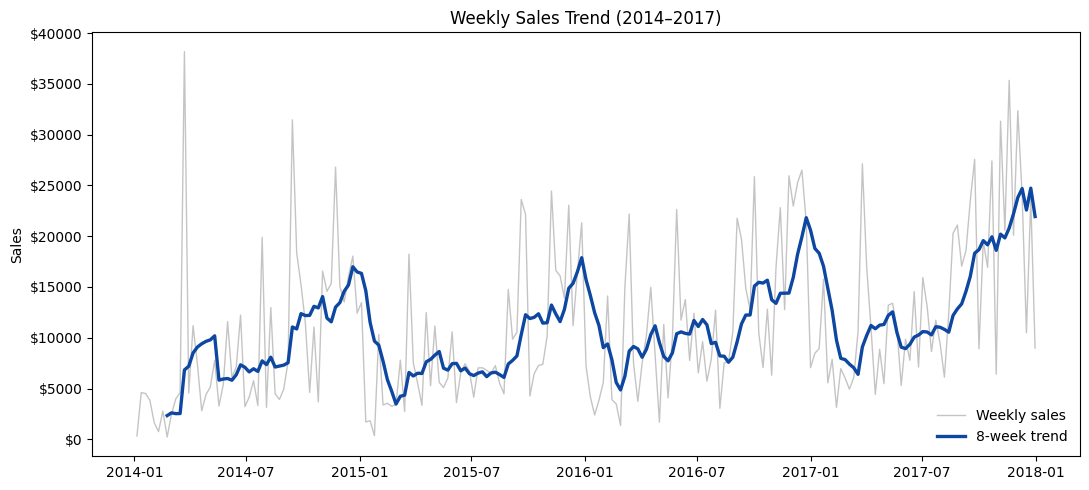

In [25]:
weekly = (
    daily.set_index("Order Date").resample("W-SUN")["TotalSales"].sum()
    .reset_index().rename(columns={"Order Date": "WeekEnding"})
)
print("Weekly series:", weekly.shape, "| zero-sales weeks:", (weekly['TotalSales']==0).sum())

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(weekly["WeekEnding"], weekly["TotalSales"], color=COLOR_GREY, linewidth=1, alpha=0.6, label="Weekly sales")
weekly["roll8"] = weekly["TotalSales"].rolling(8).mean()
ax.plot(weekly["WeekEnding"], weekly["roll8"], color=COLOR_PRIMARY, linewidth=2.4, label="8-week trend")
ax.set_title("Weekly Sales Trend (2014\u20132017)")
ax.set_ylabel("Sales"); money_fmt(ax); ax.legend(frameon=False)
fig.tight_layout(); plt.show()

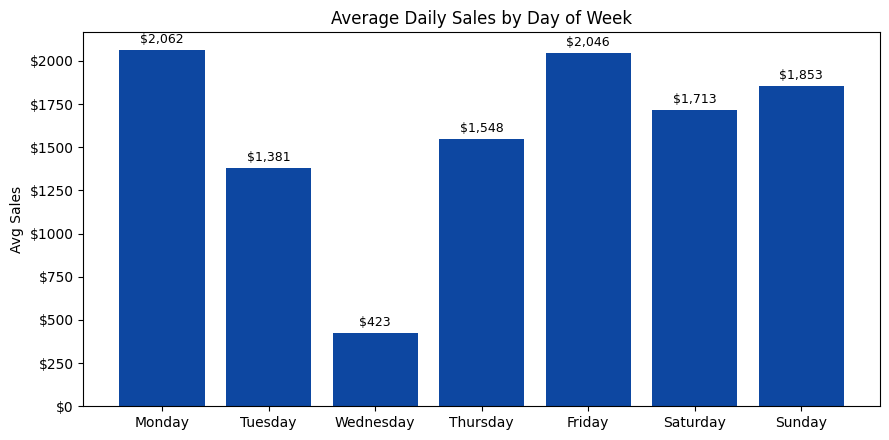

In [18]:
 # Day-of-week pattern (uses the original daily granularity, before weekly rollup)
daily["dow"] = daily["Order Date"].dt.day_name()
dow_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_avg = daily.groupby("dow")["TotalSales"].mean().reindex(dow_order)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(dow_avg.index, dow_avg.values, color=COLOR_PRIMARY)
for i, v in enumerate(dow_avg.values):
    ax.text(i, v + dow_avg.values.max()*0.02, f"${v:,.0f}", ha="center", fontsize=9)
ax.set_title("Average Daily Sales by Day of Week"); ax.set_ylabel("Avg Sales"); money_fmt(ax)
fig.tight_layout(); plt.show()


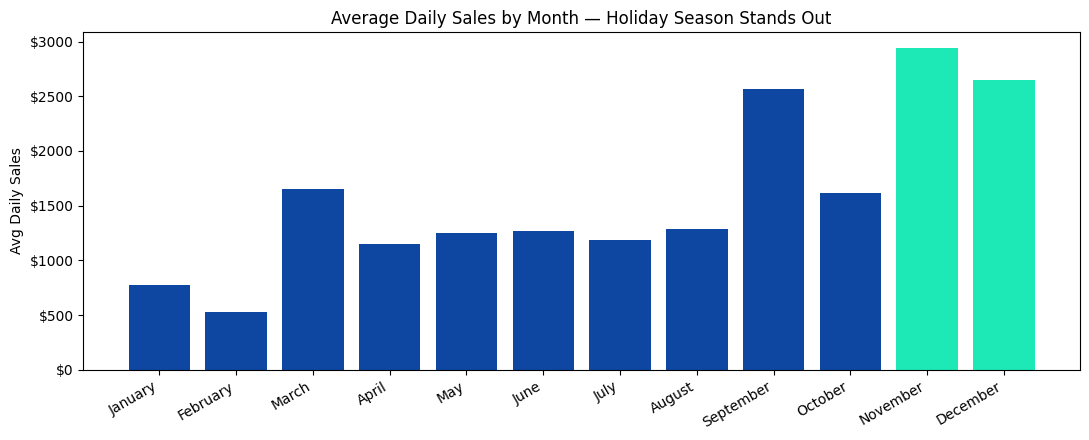

In [19]:
# Monthly pattern - where does the holiday bump actually show up?
daily["month_name"] = daily["Order Date"].dt.month_name()
month_order = ["January","February","March","April","May","June","July","August",
               "September","October","November","December"]
month_avg = daily.groupby("month_name")["TotalSales"].mean().reindex(month_order)

fig, ax = plt.subplots(figsize=(11, 4.5))
colors = [COLOR_ACCENT if m in ("November","December") else COLOR_PRIMARY for m in month_order]
ax.bar(month_avg.index, month_avg.values, color=colors)
ax.set_title("Average Daily Sales by Month \u2014 Holiday Season Stands Out")
ax.set_ylabel("Avg Daily Sales"); money_fmt(ax)
plt.setp(ax.get_xticklabels(), rotation=30, ha="right")
fig.tight_layout(); plt.show()


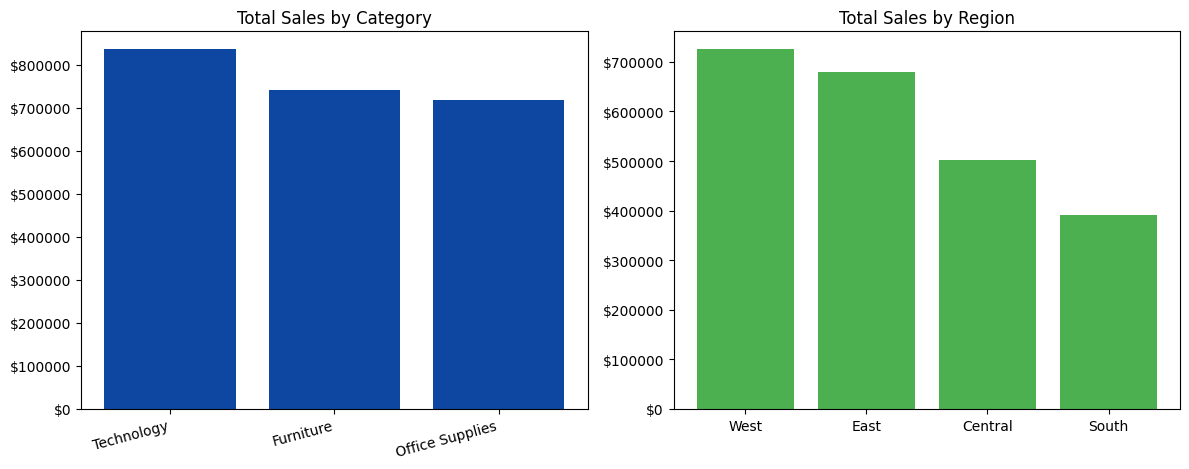

In [20]:
cat_total = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
reg_total = df.groupby("Region")["Sales"].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))
axes[0].bar(cat_total.index, cat_total.values, color=COLOR_PRIMARY)
axes[0].set_title("Total Sales by Category"); money_fmt(axes[0])
plt.setp(axes[0].get_xticklabels(), rotation=15, ha="right")
axes[1].bar(reg_total.index, reg_total.values, color=COLOR_GREEN)
axes[1].set_title("Total Sales by Region"); money_fmt(axes[1])
fig.tight_layout(); plt.show()


In [21]:
def add_calendar_features(d):
    d = d.copy()
    d["year"] = d["WeekEnding"].dt.year
    d["month"] = d["WeekEnding"].dt.month
    d["weekofyear"] = d["WeekEnding"].dt.isocalendar().week.astype(int)
    d["quarter"] = d["WeekEnding"].dt.quarter
    d["is_holiday_season"] = d["month"].isin([11, 12]).astype(int)
    d["is_q1"] = (d["quarter"] == 1).astype(int)
    return d

def add_lag_roll_features(d, target="TotalSales"):
    d = d.copy()
    for lag in [1, 2, 3, 4, 8, 12]:
        d[f"lag_{lag}"] = d[target].shift(lag)
    for win in [4, 8, 12]:
        d[f"rollmean_{win}"] = d[target].shift(1).rolling(win).mean()
        d[f"rollstd_{win}"] = d[target].shift(1).rolling(win).std()
    return d

feat = add_lag_roll_features(add_calendar_features(weekly)).dropna().reset_index(drop=True)
FEATURES = [c for c in feat.columns if c not in ["WeekEnding", "TotalSales", "roll8"]]
TARGET = "TotalSales"
print("Feature count:", len(FEATURES), "| Usable weeks after lag warm-up:", len(feat))
feat[FEATURES + [TARGET]].head()


Feature count: 18 | Usable weeks after lag warm-up: 197


,year,month,weekofyear,quarter,is_holiday_season,is_q1,lag_1,lag_2,lag_3,lag_4,lag_8,lag_12,rollmean_4,rollstd_4,rollmean_8,rollstd_8,rollmean_12,rollstd_12,TotalSales
0,2014,3,13,1,0,1,38176.809,4611.522,3982.968,2480.663,1642.310,324.044,12312.99050,17265.704575,6832.311250,12752.363411,5661.135083,10372.950215,4554.623
1,2014,4,14,2,0,0,4554.623,38176.809,4611.522,3982.968,756.888,4599.572,12831.48050,16899.269590,7196.350375,12623.962265,6013.683333,10246.185110,11193.080
2,2014,4,15,2,0,0,11193.080,4554.623,38176.809,4611.522,2780.094,4509.127,14634.00850,16001.538385,8500.874375,12400.713527,6563.142333,10339.821429,7445.859
3,2014,4,16,2,0,0,7445.859,11193.080,4554.623,38176.809,227.236,3842.388,15342.59275,15463.490152,9084.095000,12201.337344,6807.870000,10321.524241,2810.244
4,2014,4,17,2,0,0,2810.244,7445.859,11193.080,4554.623,2480.663,1642.310,6500.95150,3665.989476,9406.971000,11965.376805,6721.858000,10352.736320,4409.654


In [22]:
TEST_WEEKS = 12
train, test = feat.iloc[:-TEST_WEEKS].reset_index(drop=True), feat.iloc[-TEST_WEEKS:].reset_index(drop=True)
X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    print(f"{name:22s} MAE={mae:9.2f}  RMSE={rmse:9.2f}  MAPE={mape:6.2f}%")
    return {"model": name, "MAE": mae, "RMSE": rmse, "MAPE": mape}

results = []
baseline_pred = test["lag_4"].values
results.append(evaluate("Seasonal Naive (t-4wk)", y_test.values, baseline_pred))

lr = LinearRegression().fit(X_train, y_train)
lr_pred = lr.predict(X_test)
results.append(evaluate("Linear Regression", y_test.values, lr_pred))

rf = RandomForestRegressor(n_estimators=400, max_depth=5, min_samples_leaf=3, random_state=42, n_jobs=-1).fit(X_train, y_train)
rf_pred = rf.predict(X_test)
results.append(evaluate("Random Forest", y_test.values, rf_pred))

gb = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42).fit(X_train, y_train)
gb_pred = gb.predict(X_test)
results.append(evaluate("Gradient Boosting", y_test.values, gb_pred))

results_df = pd.DataFrame(results)
best_model_name = results_df.loc[results_df["MAE"].idxmin(), "model"]
print("\nBest model by MAE:", best_model_name)
results_df


Seasonal Naive (t-4wk) MAE=  8552.50  RMSE= 11700.45  MAPE= 62.86%
Linear Regression      MAE=  7765.71  RMSE=  9224.92  MAPE= 49.43%
Random Forest          MAE=  8259.37  RMSE=  9828.82  MAPE= 49.09%
Gradient Boosting      MAE=  7955.56  RMSE=  9599.37  MAPE= 47.89%

Best model by MAE: Linear Regression


,model,MAE,RMSE,MAPE
0,Seasonal Naive (t-4wk),8552.499233,11700.448830,62.859021
1,Linear Regression,7765.709521,9224.920700,49.432590
2,Random Forest,8259.367964,9828.821001,49.092516
3,Gradient Boosting,7955.559117,9599.366354,47.885805


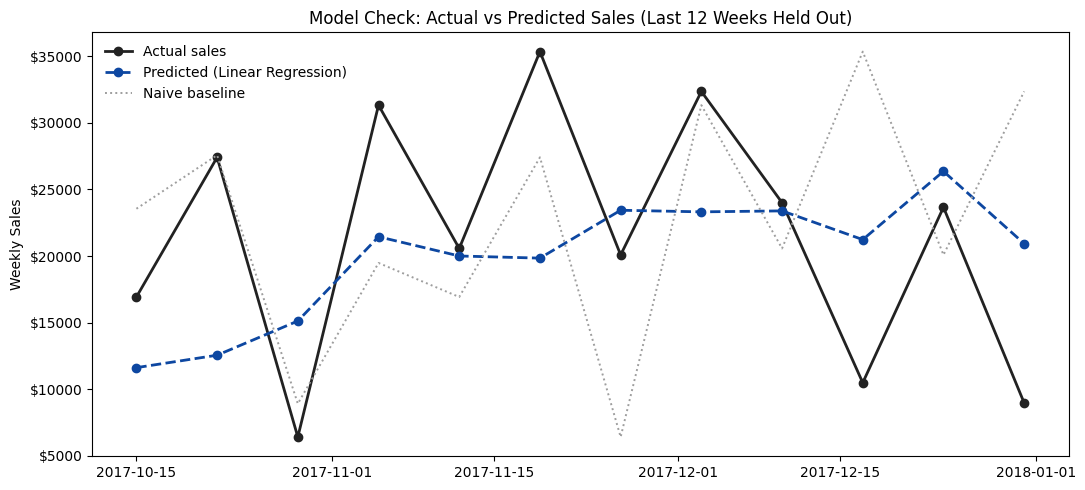

In [23]:
pred_map = {"Random Forest": rf_pred, "Gradient Boosting": gb_pred, "Linear Regression": lr_pred}
best_pred = pred_map[best_model_name]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(test["WeekEnding"], test["TotalSales"], marker="o", color="#222222", linewidth=2, label="Actual sales")
ax.plot(test["WeekEnding"], best_pred, marker="o", color=COLOR_PRIMARY, linewidth=2, linestyle="--",
        label=f"Predicted ({best_model_name})")
ax.plot(test["WeekEnding"], baseline_pred, color=COLOR_GREY, linewidth=1.4, linestyle=":", label="Naive baseline")
ax.set_title("Model Check: Actual vs Predicted Sales (Last 12 Weeks Held Out)")
ax.set_ylabel("Weekly Sales"); money_fmt(ax); ax.legend(frameon=False)
fig.tight_layout(); plt.show()


In [29]:
if best_model_name == "Random Forest":
    final_model = RandomForestRegressor(n_estimators=400, max_depth=5, min_samples_leaf=3, random_state=42, n_jobs=-1)
elif best_model_name == "Gradient Boosting":
    final_model = GradientBoostingRegressor(n_estimators=200, max_depth=2, learning_rate=0.05, random_state=42)
else:
    final_model = LinearRegression()
final_model.fit(feat[FEATURES], feat[TARGET])

FORECAST_WEEKS = 12
work = weekly[["WeekEnding", "TotalSales"]].copy()
last_week = work["WeekEnding"].max()
future_weeks = pd.date_range(last_week + pd.Timedelta(days=7), periods=FORECAST_WEEKS, freq="W-SUN")

forecast_rows = []
for wk in future_weeks:
    tmp = pd.concat([work, pd.DataFrame({"WeekEnding": [wk], "TotalSales": [np.nan]})], ignore_index=True)
    tmp_feat = add_lag_roll_features(add_calendar_features(tmp))
    pred = max(final_model.predict(tmp_feat.iloc[[-1]][FEATURES])[0], 0)
    forecast_rows.append({"WeekEnding": wk, "TotalSales": pred})
    work = pd.concat([work, pd.DataFrame({"WeekEnding": [wk], "TotalSales": [pred]})], ignore_index=True)

forecast_df = pd.DataFrame(forecast_rows)
resid_std = np.std(y_test.values - best_pred)
forecast_df["lower"] = (forecast_df["TotalSales"] - 1.28 * resid_std).clip(lower=0)
forecast_df["upper"] = forecast_df["TotalSales"] + 1.28 * resid_std
print(f"Forecast total, next {FORECAST_WEEKS} weeks: ${forecast_df['TotalSales'].sum():,.0f}")
forecast_df


Forecast total, next 12 weeks: $123,951


,WeekEnding,TotalSales,lower,upper
0,2018-01-07,10318.529490,0.000000,21964.204417
1,2018-01-14,5693.792641,0.000000,17339.467569
2,2018-01-21,10244.213343,0.000000,21889.888270
3,2018-01-28,5813.919845,0.000000,17459.594772
4,2018-02-04,10261.366305,0.000000,21907.041232
5,2018-02-11,7797.477170,0.000000,19443.152098
6,2018-02-18,9948.939294,0.000000,21594.614221
7,2018-02-25,7326.317719,0.000000,18971.992646
8,2018-03-04,12058.512474,412.837546,23704.187401
9,2018-03-11,14705.022996,3059.348069,26350.697924


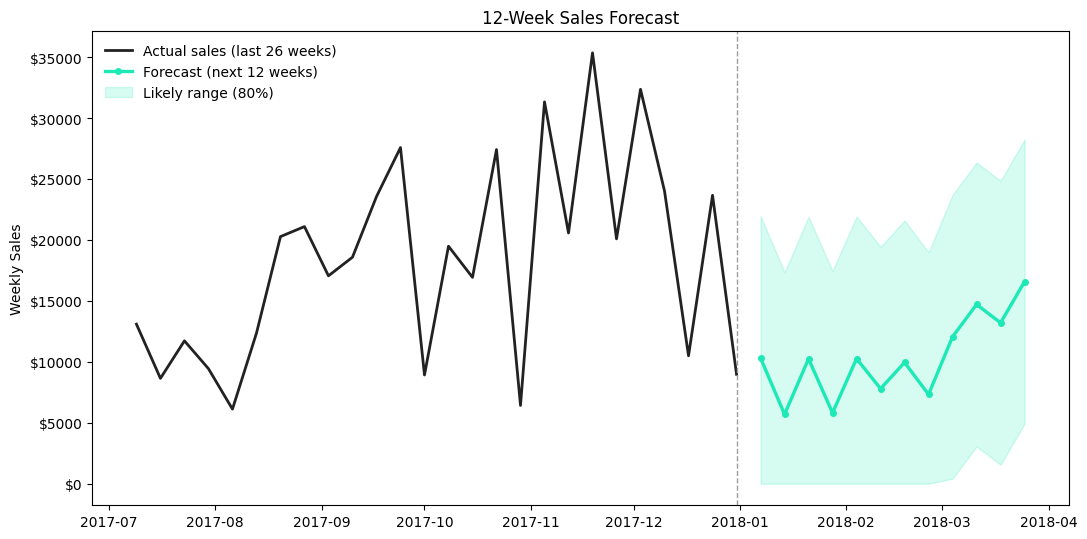

In [27]:
recent = weekly.tail(26)
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.plot(recent["WeekEnding"], recent["TotalSales"], color="#222222", linewidth=2, label="Actual sales (last 26 weeks)")
ax.plot(forecast_df["WeekEnding"], forecast_df["TotalSales"], color=COLOR_ACCENT, linewidth=2.4, marker="o",
        markersize=4, label="Forecast (next 12 weeks)")
ax.fill_between(forecast_df["WeekEnding"], forecast_df["lower"], forecast_df["upper"], color=COLOR_ACCENT,
                alpha=0.18, label="Likely range (80%)")
ax.axvline(recent["WeekEnding"].max(), color=COLOR_GREY, linestyle="--", linewidth=1)
ax.set_title("12-Week Sales Forecast"); ax.set_ylabel("Weekly Sales"); money_fmt(ax)
ax.legend(frameon=False, loc="upper left")
fig.tight_layout(); plt.show()
